# Graph Search on a City Network

This notebook loads a graph of cities from a JSON file, visualizes the network,
and applies different search algorithms to find paths between pairs of cities.

The current implementation includes:
- Breadth-First Search (BFS)
- Uniform Cost Search (UCS)
- A* Search
- Bidirectional BFS

For each algorithm, the notebook also collects empirical metrics related to:
- time complexity, measured as the number of expanded nodes
- space complexity, measured as the maximum number of nodes stored in memory

In [1]:
from algorithm import bfs, uniform_cost_search, a_star_search, bidirectional_bfs
from utils import load_map_from_json, load_weighted_graph_from_json, draw_path, draw_graph, draw_cities,heuristic

## Load the dataset

The JSON file contains:
- the coordinates of each city
- the neighboring cities
- the distances between connected cities

In [2]:
data, graph = load_map_from_json("cities.json")
_, weighted_graph = load_weighted_graph_from_json("cities.json")

In [3]:
# Number of cities
num_cities = len(data)

# Number of undirected edges, counted only once
unique_edges = set()

for city, info in data.items():
    for neighbor in info["neighbours"]:
        edge = tuple(sorted((city, neighbor)))
        unique_edges.add(edge)

num_edges = len(unique_edges)

print(f"Number of cities: {num_cities}")
print(f"Number of edges: {num_edges}")

Number of cities: 58
Number of edges: 120


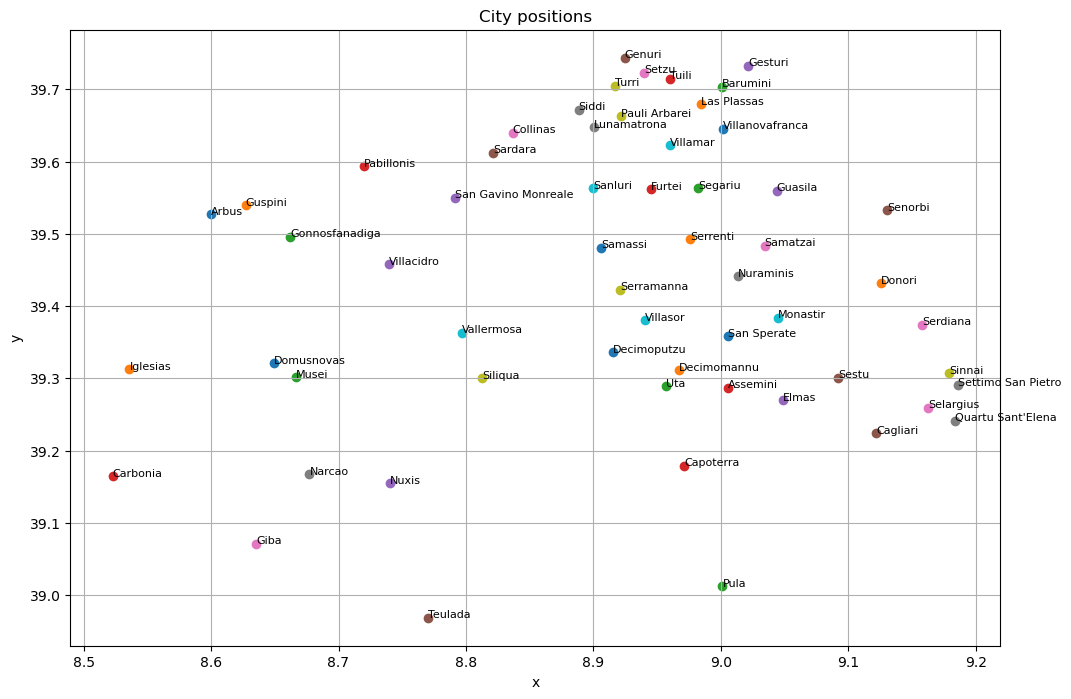

In [4]:
draw_cities(data)

## Define multiple search tasks

Each tuple represents a pathfinding problem in the form:

(start_city, goal_city)

The same set of problems will be solved by all implemented algorithms,
so their behavior and empirical metrics can be compared consistently.

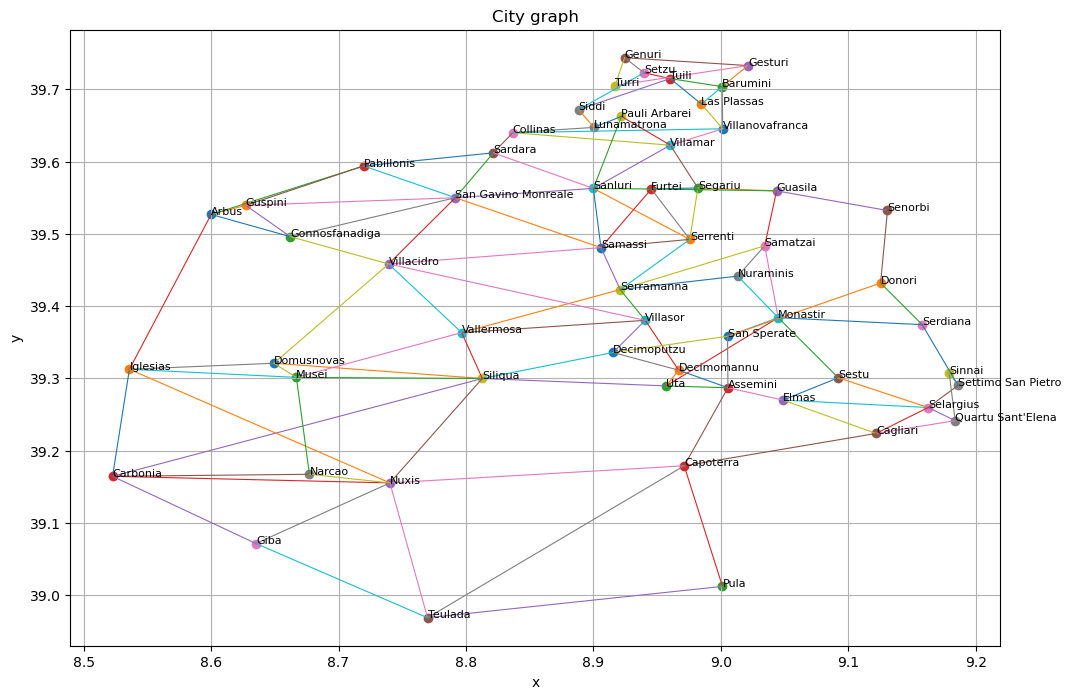

In [5]:
problems = [
    ("Serrenti", "Pula"),
    ("Arbus", "Pauli Arbarei"),
    ("Pabillonis", "Selargius"),
    ("Giba","Las Plassas")
]

implemented_algorithms = [
    {
        "name": "BFS",
        "function": bfs
    },
    {
        "name": "Uniform Cost Search",
        "function": uniform_cost_search
    },
    {
        "name": "A* Search",
        "function": a_star_search
    },
    {
        "name": "Bidirectional BFS",
        "function": bidirectional_bfs
    }
]
draw_graph(data)

## Run all search algorithms on the selected tasks

For each start-goal pair, the notebook:
1. runs each implemented search algorithm
2. prints the resulting path
3. prints the order of node expansion
4. prints the empirical metrics
5. visualizes the final path on the graph



Problem: Serrenti -> Pula


Running BFS...
Path found: ['Serrenti', 'Serramanna', 'Vallermosa', 'Siliqua', 'Nuxis', 'Capoterra', 'Pula']
Metrics: {'expanded_nodes': 58, 'max_frontier_size': 16, 'max_nodes_in_memory': 58, 'path_cost': 137.1}


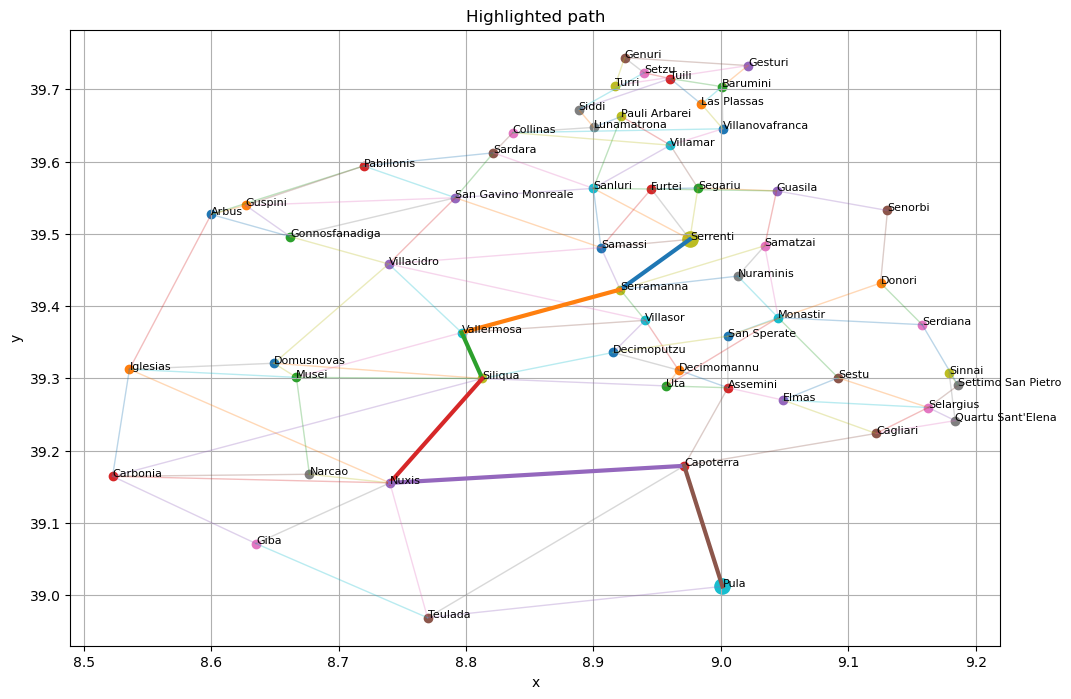


Running Uniform Cost Search...
Path found: ['Serrenti', 'Serramanna', 'Villasor', 'Decimomannu', 'Assemini', 'Capoterra', 'Pula']
Metrics: {'expanded_nodes': 55, 'max_frontier_size': 20, 'max_nodes_in_memory': 58, 'path_cost': 70.1}


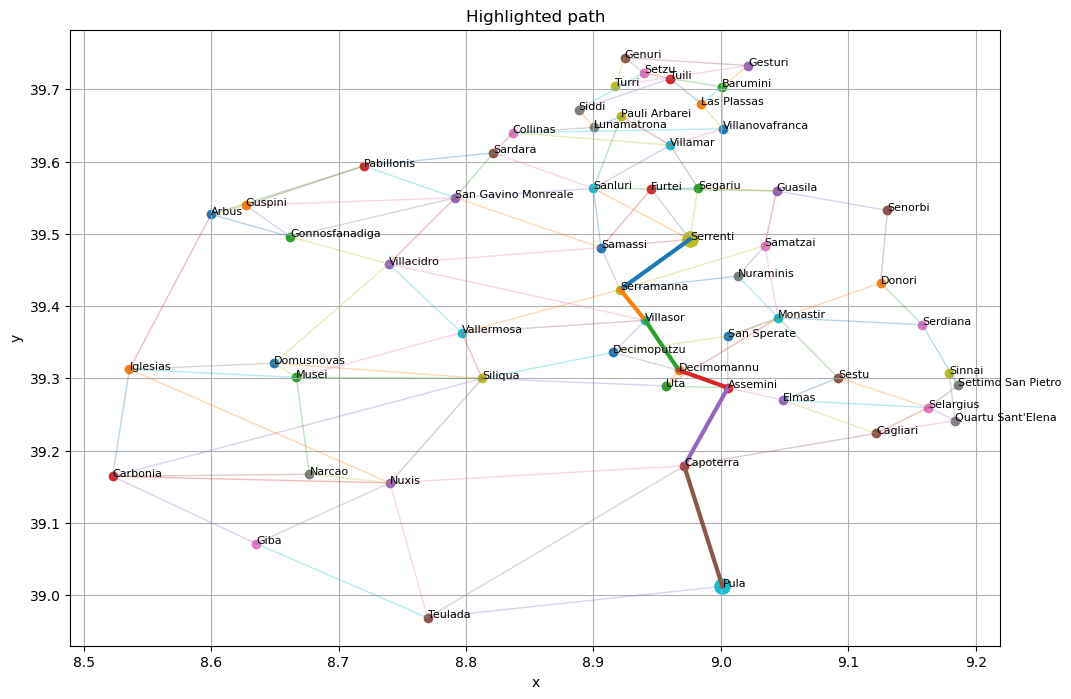


Running A* Search...
Path found: ['Serrenti', 'Serramanna', 'Villasor', 'Decimomannu', 'Assemini', 'Capoterra', 'Pula']
Metrics: {'expanded_nodes': 12, 'max_frontier_size': 18, 'max_nodes_in_memory': 28, 'path_cost': 70.1}


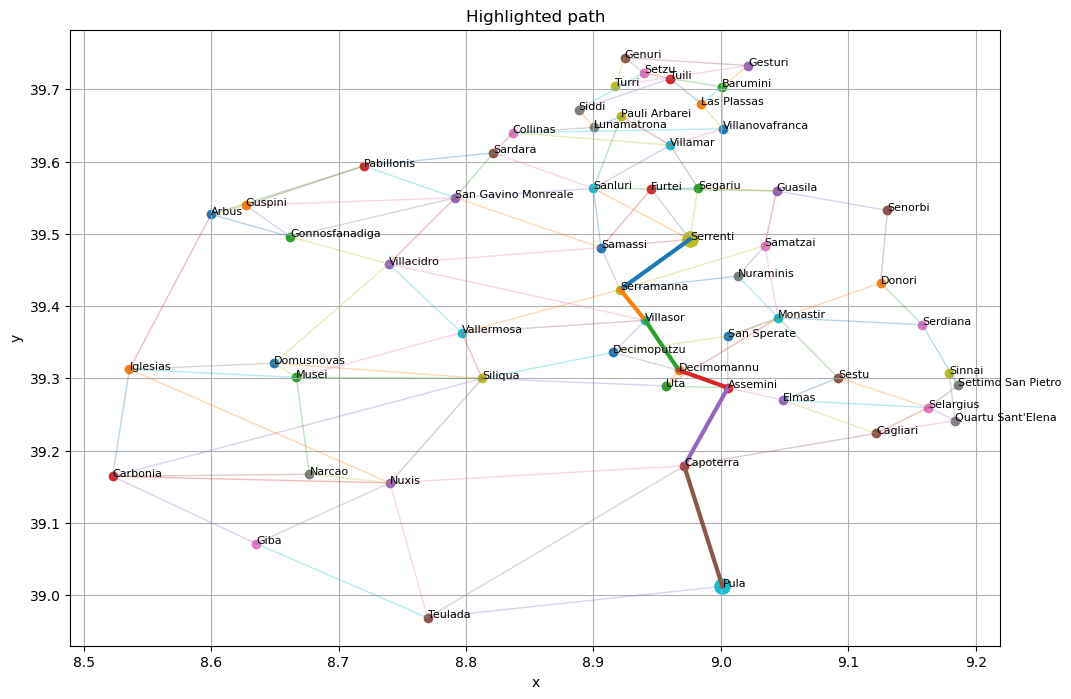


Running Bidirectional BFS...
Path found: ['Serrenti', 'Serramanna', 'Villasor', 'Decimomannu', 'Assemini', 'Capoterra', 'Pula']
Metrics: {'expanded_nodes': 20, 'max_frontier_size': 17, 'max_nodes_in_memory': 36, 'path_cost': 70.1}


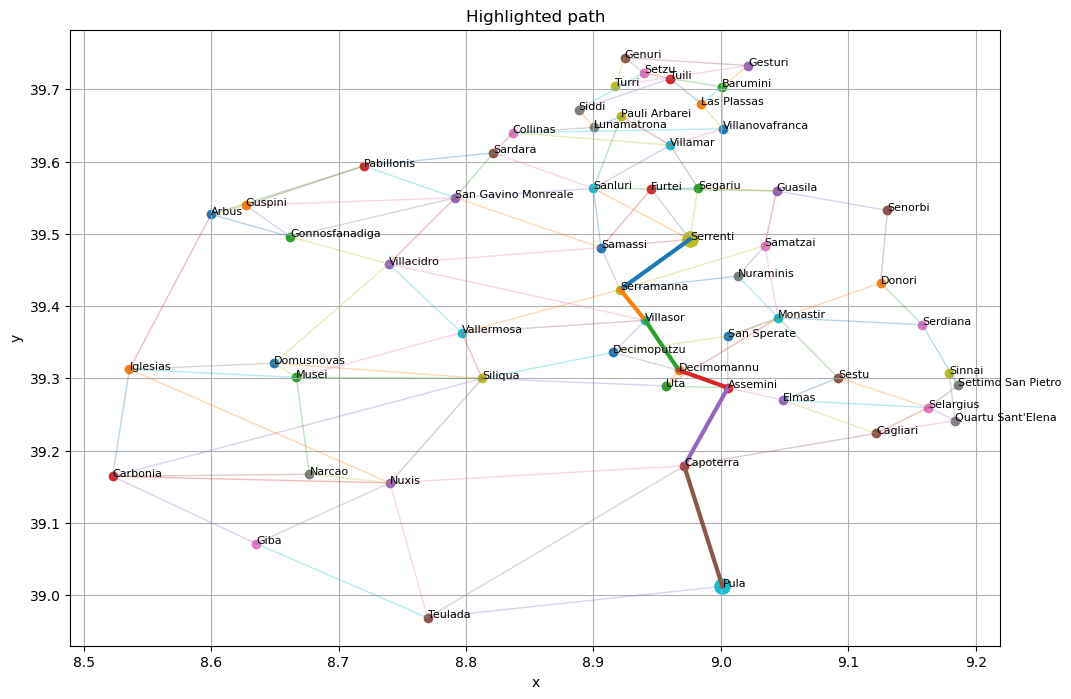


Problem: Arbus -> Pauli Arbarei


Running BFS...
Path found: ['Arbus', 'Gonnosfanadiga', 'San Gavino Monreale', 'Sanluri', 'Pauli Arbarei']
Metrics: {'expanded_nodes': 26, 'max_frontier_size': 15, 'max_nodes_in_memory': 39, 'path_cost': 50.9}


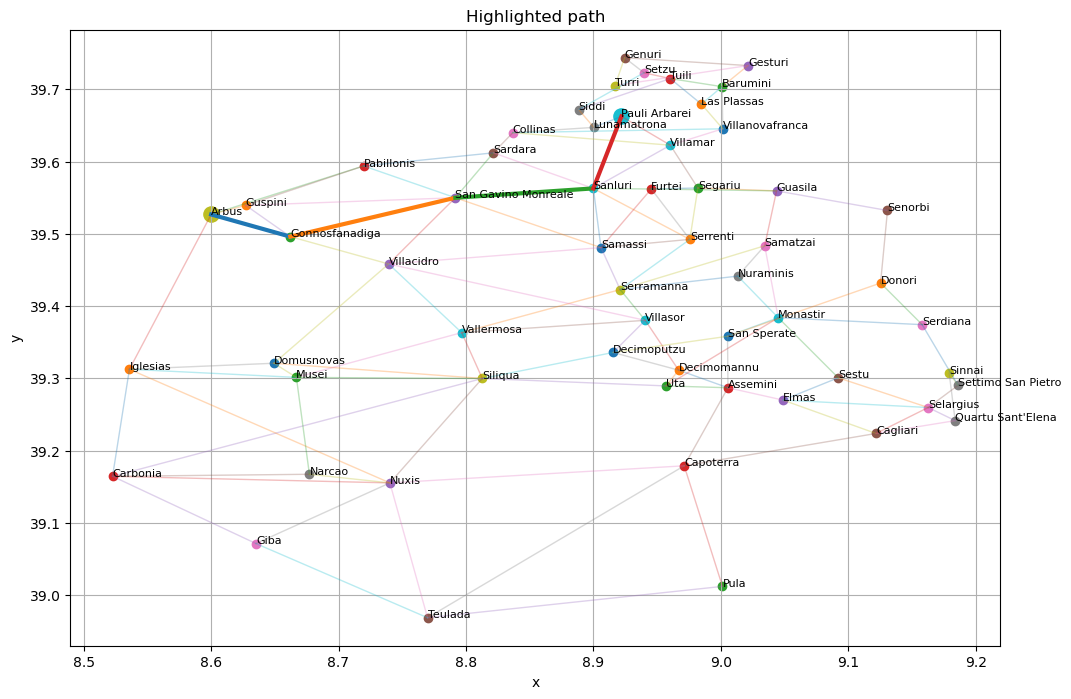


Running Uniform Cost Search...
Path found: ['Arbus', 'Pabillonis', 'Sardara', 'Collinas', 'Lunamatrona', 'Pauli Arbarei']
Metrics: {'expanded_nodes': 15, 'max_frontier_size': 16, 'max_nodes_in_memory': 26, 'path_cost': 43.1}


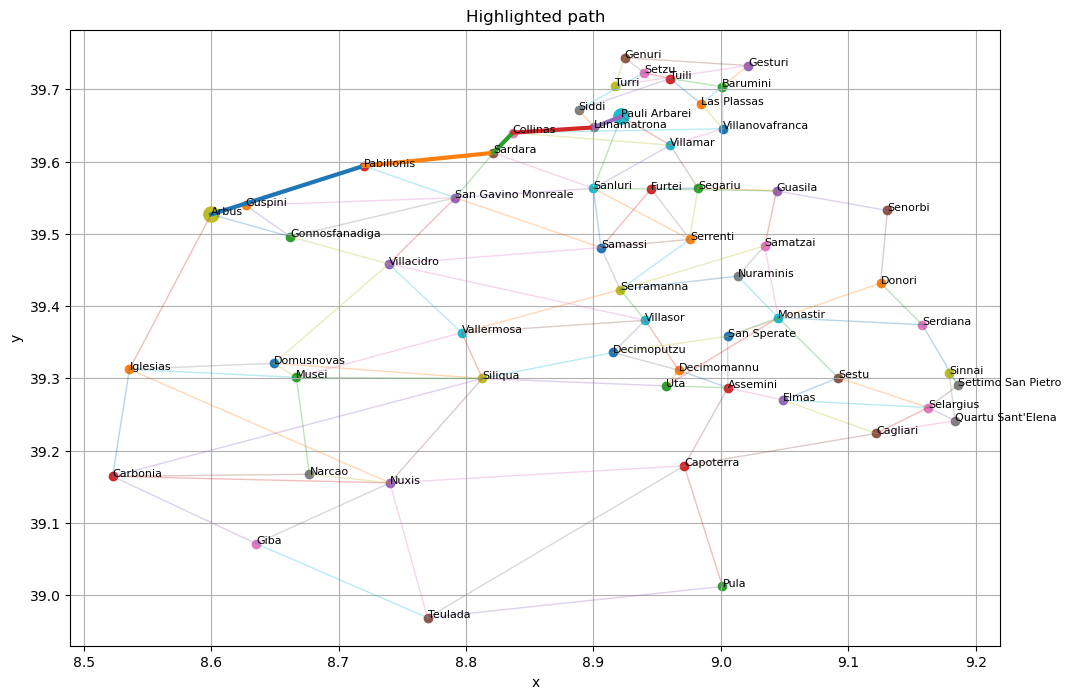


Running A* Search...
Path found: ['Arbus', 'Pabillonis', 'Sardara', 'Collinas', 'Lunamatrona', 'Pauli Arbarei']
Metrics: {'expanded_nodes': 9, 'max_frontier_size': 9, 'max_nodes_in_memory': 16, 'path_cost': 43.1}


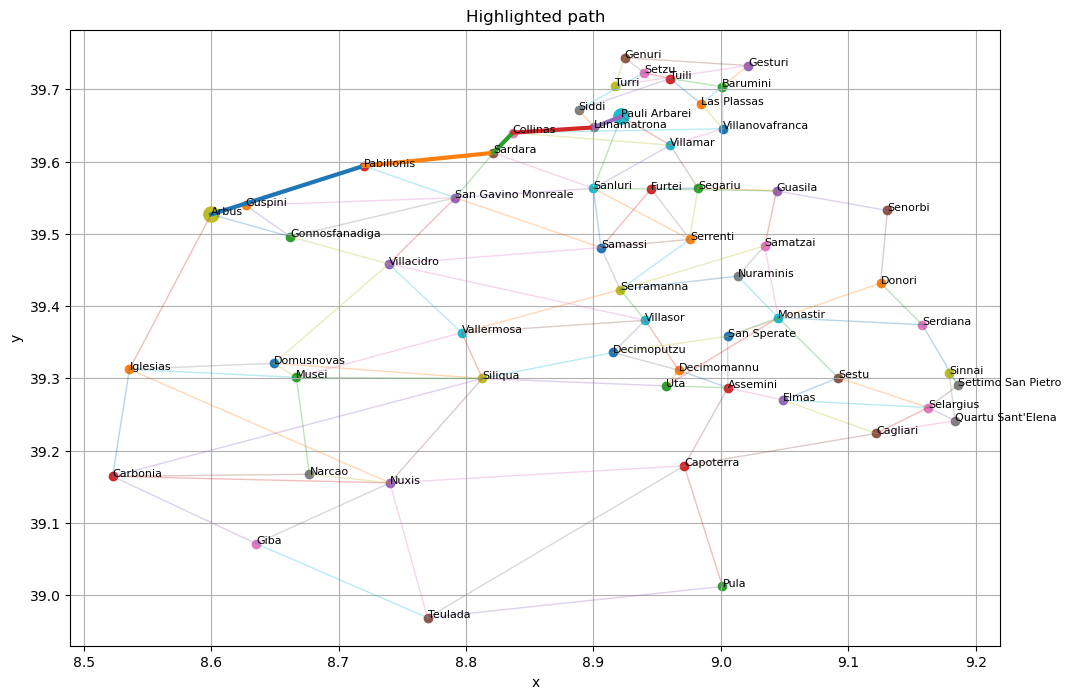


Running Bidirectional BFS...
Path found: ['Arbus', 'Pabillonis', 'Sardara', 'Sanluri', 'Pauli Arbarei']
Metrics: {'expanded_nodes': 8, 'max_frontier_size': 12, 'max_nodes_in_memory': 19, 'path_cost': 51.4}


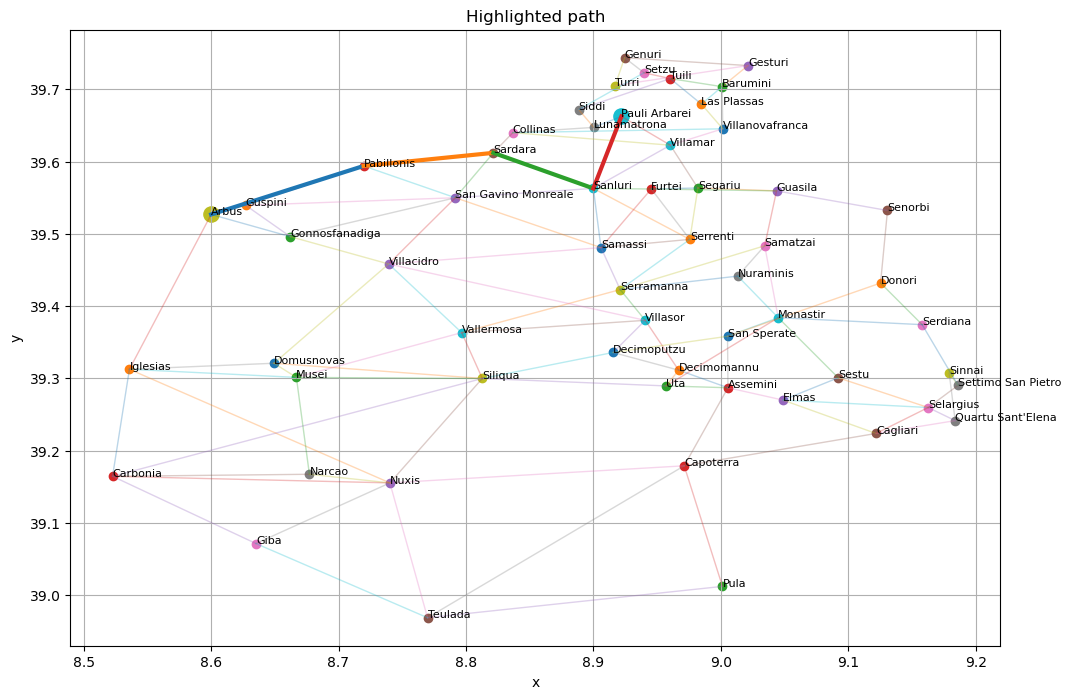


Problem: Pabillonis -> Selargius


Running BFS...
Path found: ['Pabillonis', 'Arbus', 'Iglesias', 'Nuxis', 'Capoterra', 'Cagliari', 'Selargius']
Metrics: {'expanded_nodes': 51, 'max_frontier_size': 16, 'max_nodes_in_memory': 57, 'path_cost': 177.4}


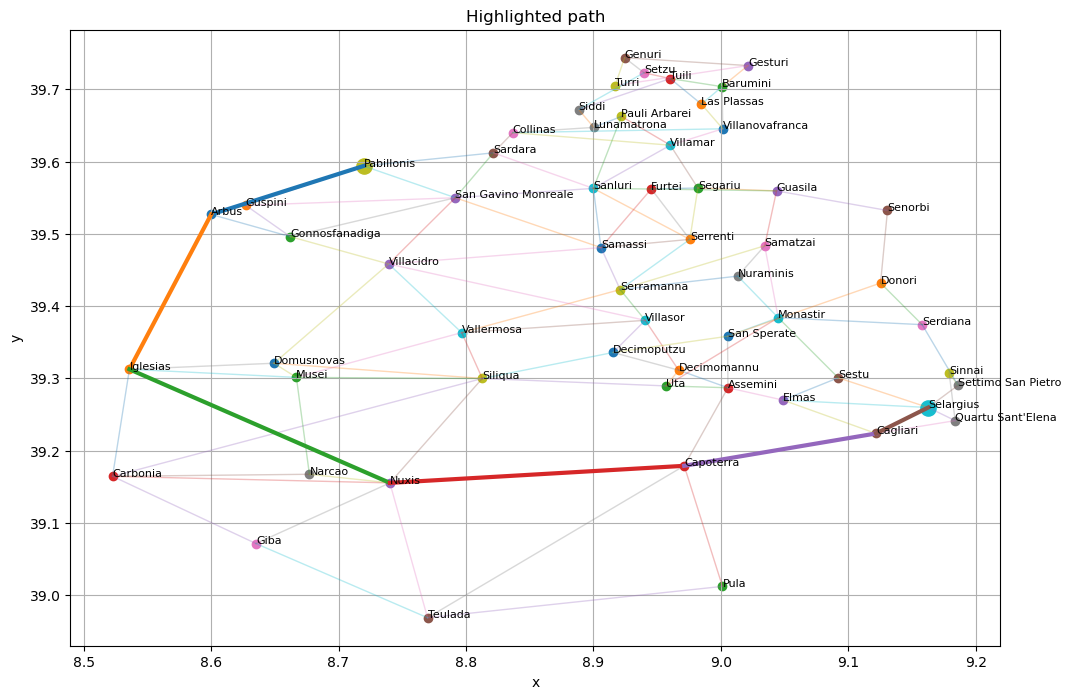


Running Uniform Cost Search...
Path found: ['Pabillonis', 'San Gavino Monreale', 'Samassi', 'Serramanna', 'Villasor', 'Decimomannu', 'Assemini', 'Elmas', 'Selargius']
Metrics: {'expanded_nodes': 48, 'max_frontier_size': 15, 'max_nodes_in_memory': 54, 'path_cost': 75.4}


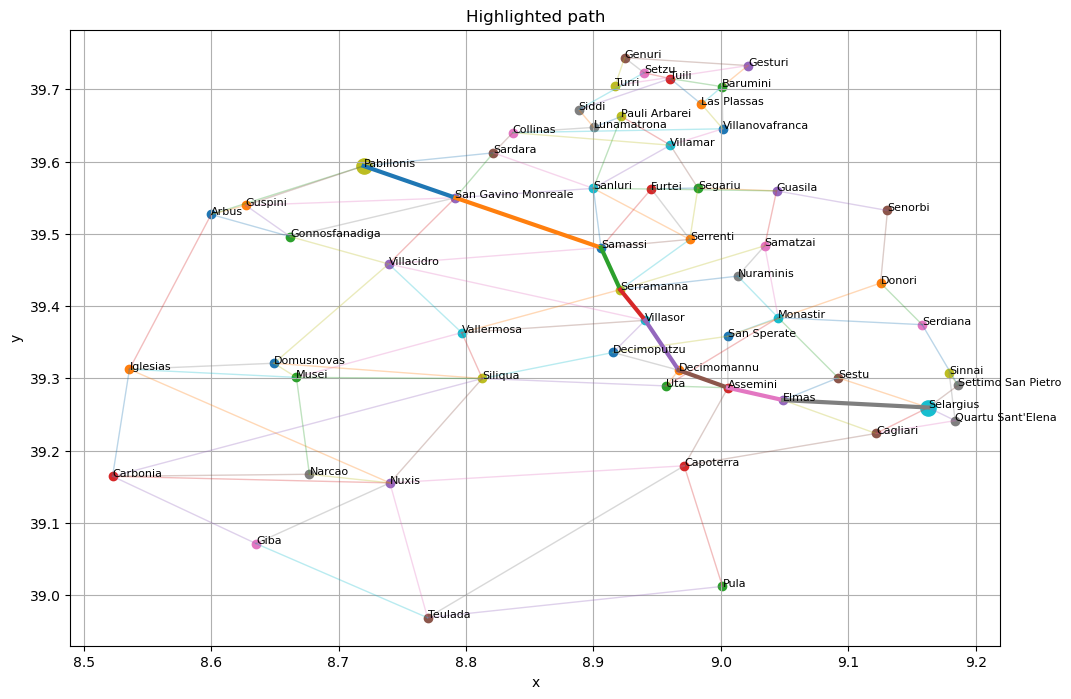


Running A* Search...
Path found: ['Pabillonis', 'San Gavino Monreale', 'Samassi', 'Serramanna', 'Villasor', 'Decimomannu', 'Assemini', 'Elmas', 'Selargius']
Metrics: {'expanded_nodes': 28, 'max_frontier_size': 23, 'max_nodes_in_memory': 41, 'path_cost': 75.4}


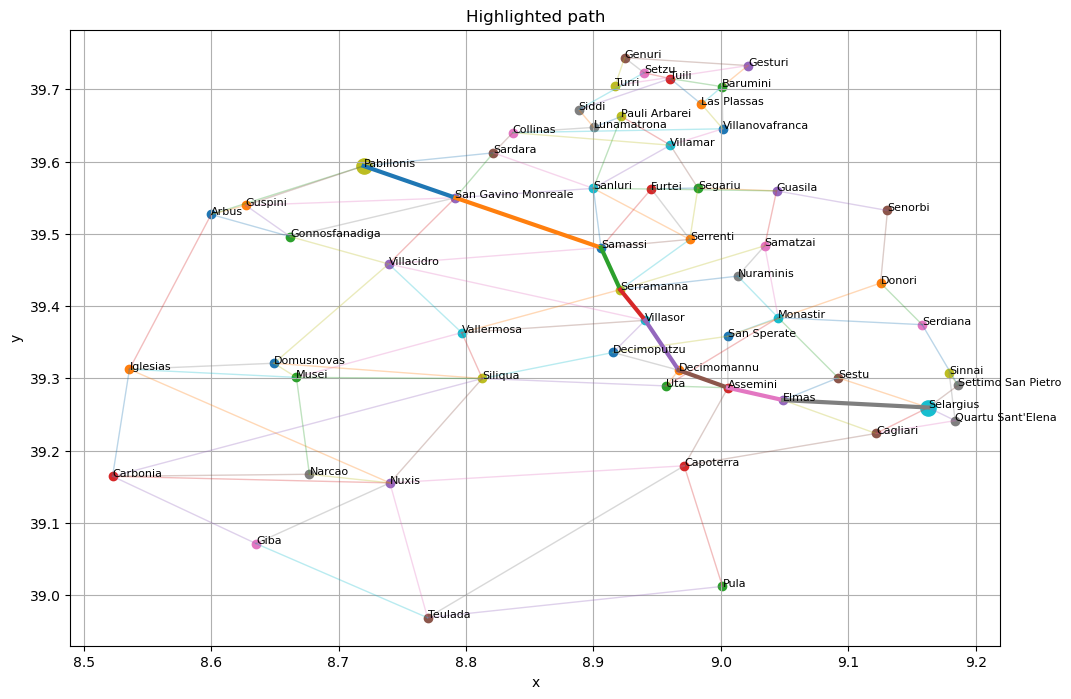


Running Bidirectional BFS...
Path found: ['Pabillonis', 'Arbus', 'Iglesias', 'Nuxis', 'Capoterra', 'Cagliari', 'Selargius']
Metrics: {'expanded_nodes': 18, 'max_frontier_size': 19, 'max_nodes_in_memory': 36, 'path_cost': 177.4}


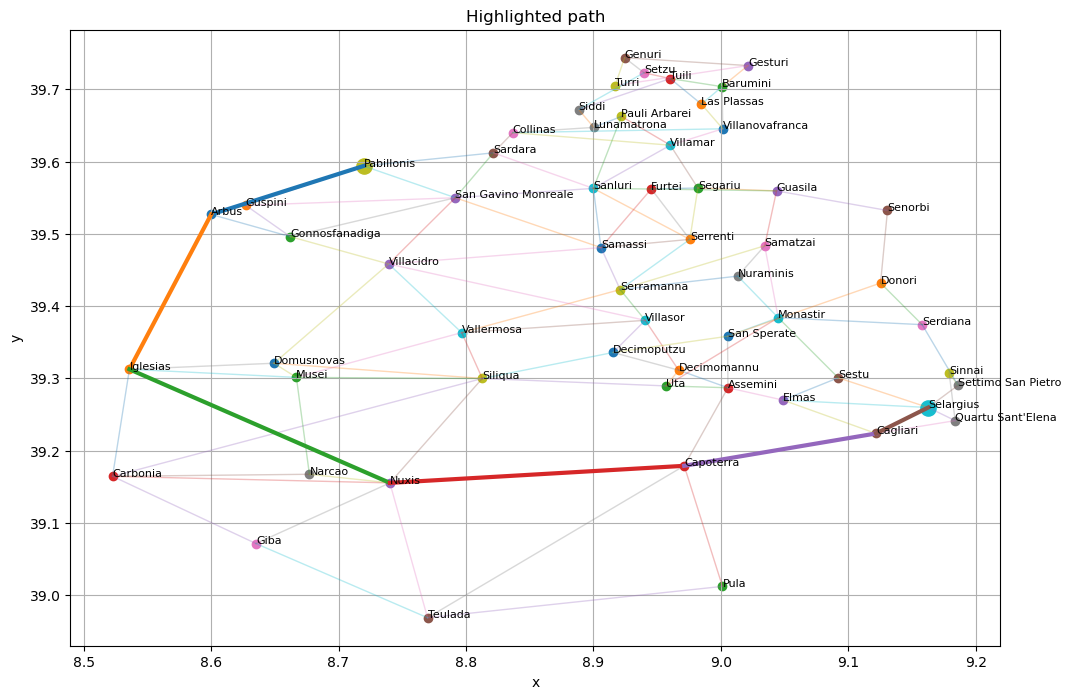


Problem: Giba -> Las Plassas


Running BFS...
Path found: ['Giba', 'Nuxis', 'Iglesias', 'Arbus', 'Pabillonis', 'Sardara', 'Collinas', 'Villanovafranca', 'Las Plassas']
Metrics: {'expanded_nodes': 53, 'max_frontier_size': 12, 'max_nodes_in_memory': 56, 'path_cost': 157.1}


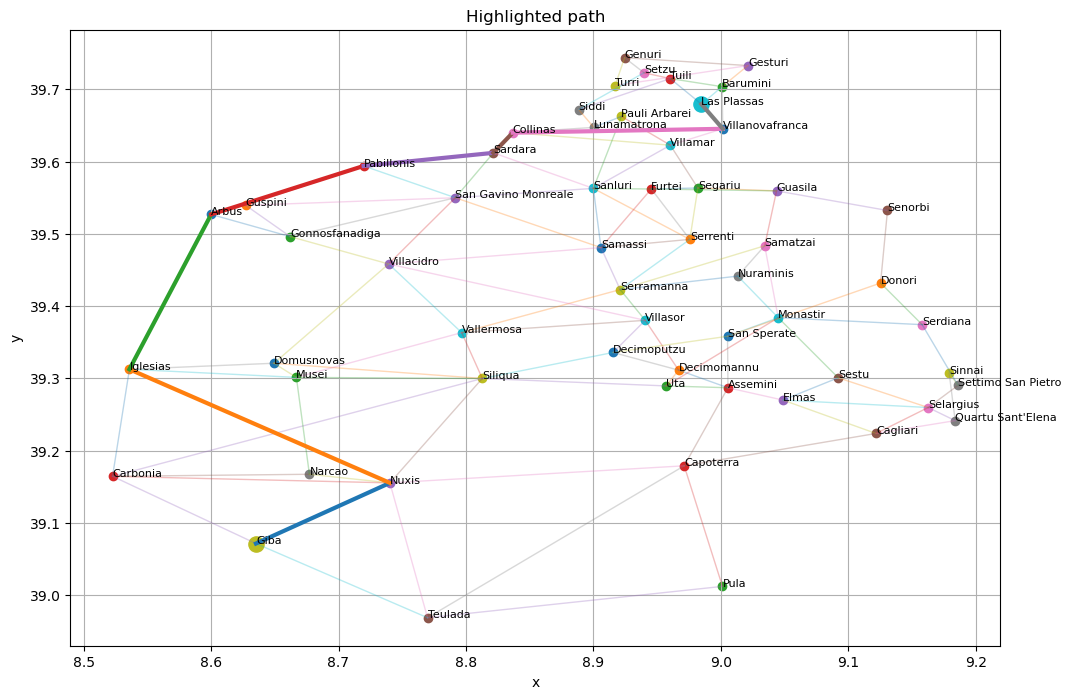


Running Uniform Cost Search...
Path found: ['Giba', 'Nuxis', 'Siliqua', 'Decimoputzu', 'Villasor', 'Serramanna', 'Samassi', 'Sanluri', 'Villamar', 'Villanovafranca', 'Las Plassas']
Metrics: {'expanded_nodes': 52, 'max_frontier_size': 19, 'max_nodes_in_memory': 55, 'path_cost': 107.4}


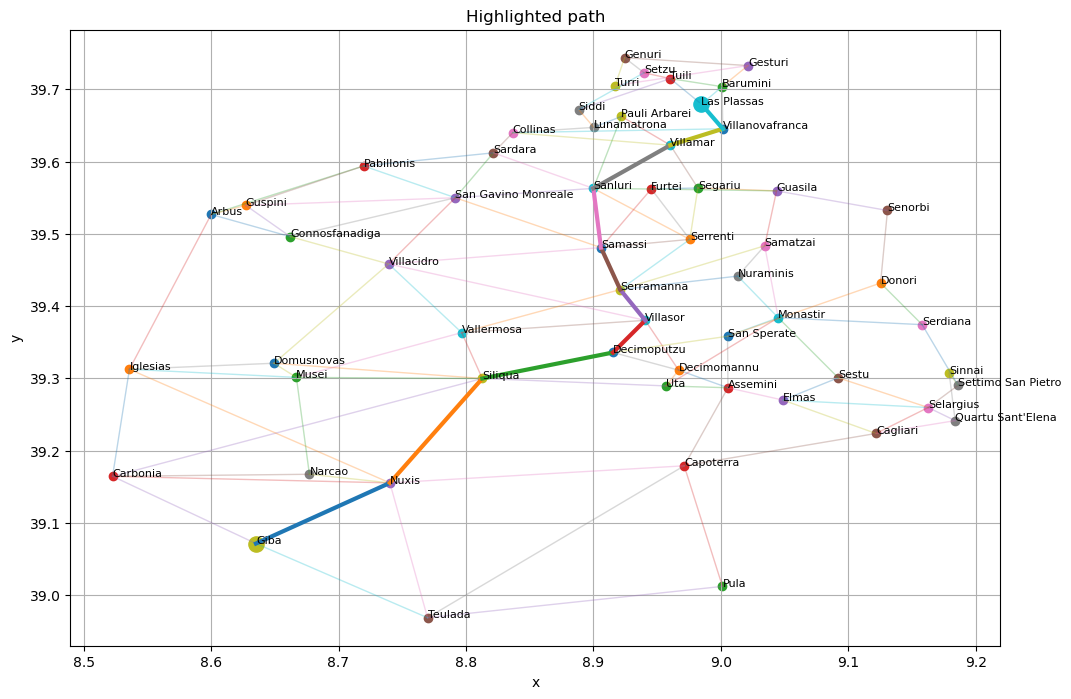


Running A* Search...
Path found: ['Giba', 'Nuxis', 'Siliqua', 'Decimoputzu', 'Villasor', 'Serramanna', 'Samassi', 'Sanluri', 'Villamar', 'Villanovafranca', 'Las Plassas']
Metrics: {'expanded_nodes': 33, 'max_frontier_size': 24, 'max_nodes_in_memory': 48, 'path_cost': 107.4}


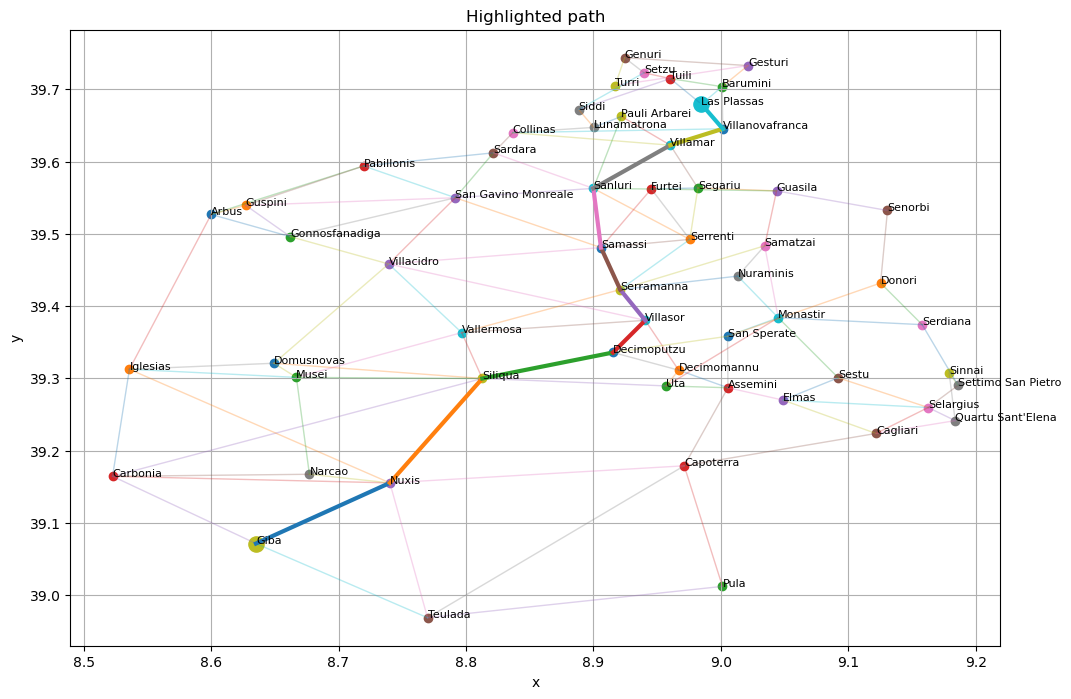


Running Bidirectional BFS...
Path found: ['Giba', 'Nuxis', 'Iglesias', 'Arbus', 'Pabillonis', 'Sardara', 'Collinas', 'Villanovafranca', 'Las Plassas']
Metrics: {'expanded_nodes': 30, 'max_frontier_size': 19, 'max_nodes_in_memory': 45, 'path_cost': 157.1}


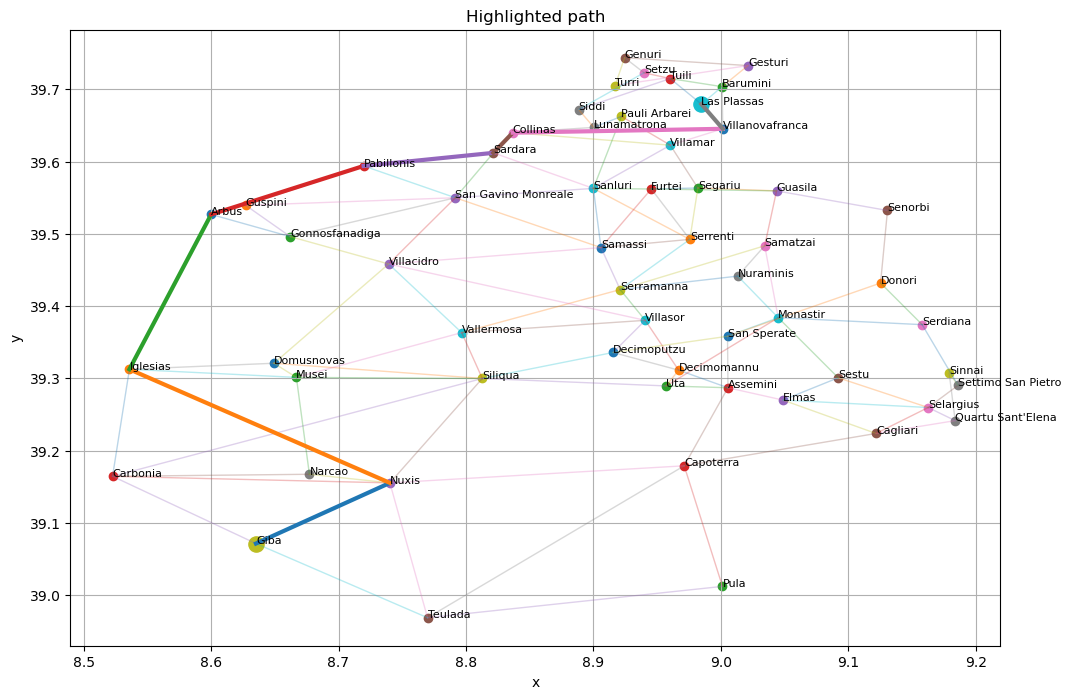

In [6]:
results = []

for start, goal in problems:
    print(f"\nProblem: {start} -> {goal}\n")

    for algorithm in implemented_algorithms:
        algorithm_name = algorithm["name"]
        algorithm_function = algorithm["function"]

        print(f"\nRunning {algorithm_name}...")

        path, visited_order, metrics = algorithm_function(
            graph=graph,
            start=start,
            goal=goal,
            verbose=False,
            weighted_graph=weighted_graph,
            data=data
        )

        print(f"Path found: {path}")
        print(f"Metrics: {metrics}")

        results.append({
            "problem": f"{start} -> {goal}",
            "algorithm": algorithm_name,
            "path": path,
            "visited_order": visited_order,
            "metrics": metrics
        })

        draw_path(data, path)

In [7]:
import pandas as pd

df_metrics = pd.DataFrame([
    {
        "problem": r["problem"],
        "algorithm": r["algorithm"],
        "path_cost": r["metrics"]["path_cost"],
        "expanded_nodes": r["metrics"]["expanded_nodes"],
        "max_nodes_in_memory": r["metrics"]["max_nodes_in_memory"]
    }
    for r in results
])

df_metrics

,problem,algorithm,path_cost,expanded_nodes,max_nodes_in_memory
0,Serrenti -> Pula,BFS,137.1,58,58
1,Serrenti -> Pula,Uniform Cost Search,70.1,55,58
2,Serrenti -> Pula,A* Search,70.1,12,28
3,Serrenti -> Pula,Bidirectional BFS,70.1,20,36
4,Arbus -> Pauli Arbarei,BFS,50.9,26,39
5,Arbus -> Pauli Arbarei,Uniform Cost Search,43.1,15,26
6,Arbus -> Pauli Arbarei,A* Search,43.1,9,16
7,Arbus -> Pauli Arbarei,Bidirectional BFS,51.4,8,19
8,Pabillonis -> Selargius,BFS,177.4,51,57
9,Pabillonis -> Selargius,Uniform Cost Search,75.4,48,54


## Full evaluation on all non-adjacent city pairs

We performed a more systematic evaluation on all unordered pairs of distinct cities in the graph, excluding adjacent pairs. Adjacent pairs were excluded because they correspond to trivial instances, where the solution is found in one step.

For each non-adjacent start–goal pair, we first computed the optimal solution depth, defined as the minimum number of edges in a path connecting the two cities. This value was obtained using Breadth-First Search, since BFS is the appropriate strategy to identify the shortest path in terms of number of steps in an unweighted graph representation.

Then, for the same pair, all the implemented search strategies were executed and the following metrics were collected:
- path cost
- number of expanded nodes
- maximum number of nodes in memory.

This produces a complete benchmark over the whole set of non-trivial problem instances in the map.

In [8]:
from itertools import combinations
import pandas as pd

implemented_algorithms = [
    {"name": "BFS", "function": bfs},
    {"name": "Uniform Cost Search", "function": uniform_cost_search},
    {"name": "A* Search", "function": a_star_search},
    {"name": "Bidirectional BFS", "function": bidirectional_bfs}
]

all_results = []

cities = sorted(graph.keys())

for start, goal in combinations(cities, 2):
    if goal in graph[start]:
        continue

    optimal_path, _, _ = bfs(
        graph=graph,
        start=start,
        goal=goal,
        verbose=False,
        weighted_graph=weighted_graph,
        data=data
    )

    if optimal_path is None:
        continue

    optimal_depth = len(optimal_path) - 1

    for algorithm in implemented_algorithms:
        algorithm_name = algorithm["name"]
        algorithm_function = algorithm["function"]

        path, visited_order, metrics = algorithm_function(
            graph=graph,
            start=start,
            goal=goal,
            verbose=False,
            weighted_graph=weighted_graph,
            data=data
        )

        returned_depth = None if path is None else len(path) - 1

        all_results.append({
            "start": start,
            "goal": goal,
            "algorithm": algorithm_name,
            "optimal_depth": optimal_depth,
            "returned_depth": returned_depth,
            "path_cost": metrics["path_cost"],
            "expanded_nodes": metrics["expanded_nodes"],
            "max_nodes_in_memory": metrics["max_nodes_in_memory"]
        })

df_all = pd.DataFrame(all_results)
df_all.head()

,start,goal,algorithm,optimal_depth,returned_depth,path_cost,expanded_nodes,max_nodes_in_memory
0,Arbus,Assemini,BFS,4,4,146.9,33,44
1,Arbus,Assemini,Uniform Cost Search,4,5,59.3,34,45
2,Arbus,Assemini,A* Search,4,5,59.3,9,20
3,Arbus,Assemini,Bidirectional BFS,4,4,146.9,7,20
4,Arbus,Barumini,BFS,5,5,64.3,42,51


## Aggregated statistics by optimal depth

In order to summarize the results in a more informative way, all problem instances were grouped by optimal solution depth d. More precisely, for each algorithm and for each depth value d, we considered all start–goal pairs whose optimal solution has depth d.

For every group, we computed:
- the number of instances,
- the mean and standard deviation of path cost,
- the mean and standard deviation of expanded nodes,
- the mean and standard deviation of maximum nodes in memory.

This aggregated view makes it possible to compare the behavior of the different search strategies on instances of comparable structural difficulty, instead of focusing only on a small number of individual examples.

In [9]:
summary_df = (
    df_all
    .groupby(["algorithm", "optimal_depth"])
    .agg(
        instances=("path_cost", "size"),
        mean_path_cost=("path_cost", "mean"),
        std_path_cost=("path_cost", "std"),
        mean_expanded_nodes=("expanded_nodes", "mean"),
        std_expanded_nodes=("expanded_nodes", "std"),
        mean_max_nodes_in_memory=("max_nodes_in_memory", "mean"),
        std_max_nodes_in_memory=("max_nodes_in_memory", "std")
    )
    .reset_index()
    .sort_values(["algorithm", "optimal_depth"])
)

summary_df = summary_df.round(2)
summary_df

,algorithm,optimal_depth,instances,mean_path_cost,std_path_cost,mean_expanded_nodes,std_expanded_nodes,mean_max_nodes_in_memory,std_max_nodes_in_memory
0,A* Search,2,231,26.97,14.42,4.78,2.36,11.19,4.25
1,A* Search,3,305,39.63,17.05,7.94,3.79,16.70,5.93
2,A* Search,4,304,50.65,17.89,11.68,4.75,22.20,6.67
3,A* Search,5,229,58.36,18.03,15.43,6.23,27.10,7.28
4,A* Search,6,164,63.39,16.71,19.44,7.43,31.24,7.88
5,A* Search,7,115,70.48,16.70,23.37,7.51,34.84,7.66
6,A* Search,8,84,79.14,17.16,28.85,7.65,40.33,7.15
7,A* Search,9,60,86.97,17.73,33.92,6.75,44.57,6.11
8,A* Search,10,31,94.36,17.56,37.97,6.56,47.61,5.53
9,A* Search,11,10,96.27,11.25,39.30,4.64,49.30,4.57
